
# Energy & Climate Structural Estimation — OWID CO₂ Data

This notebook replicates the **same learning logic** used in `Speed_Dating_Analysis_Final.ipynb`, but translates the idea from **dating choices** to **energy & climate outcomes**.

## Core idea for the video

In the speed-dating notebook, the question was:

> What makes a person say **“Yes”**?

Here, the analogous climate question is:

> What makes a country-year say **“Yes” to a green transition outcome**?

Because the OWID CO₂ dataset is not a survey or true policy-choice experiment, this is not a full dynamic structural model. It is a **pedagogical structural-style binary logit exercise**: we define a binary outcome and estimate which observable energy-economic conditions are associated with that outcome.

The default target is:

\[
GreenTransition_{c,t}=1
\]

when country \(c\) experiences **positive GDP growth** while **territorial CO₂ emissions decline** in year \(t\).

That makes the model intuitive for the video:  
**Speed dating:** “Does the person say yes?”  
**Climate:** “Does the country-year achieve growth with lower emissions?”



## 1. Structural Estimation Logic

We use a Binary Logit model:

\[
P(Y_{c,t}=1)=\frac{1}{1+e^{-(\beta_0+\beta_1X_{1,c,t-1}+...+\beta_kX_{k,c,t-1})}}
\]

or equivalently:

\[
\log\left(\frac{P}{1-P}\right)=\beta_0+\beta_1X_{1,c,t-1}+...+\beta_kX_{k,c,t-1}
\]

Interpretation:

- \(Y=1\): the country-year achieves the selected green-transition outcome.
- \(X\): lagged structural conditions, such as income, energy intensity, carbon intensity, and fossil-fuel composition.
- \(\beta\): estimated preference/structural parameters in a simplified static utility model.
- Lagging the variables by one year avoids using same-year information to explain the same-year outcome.

### Important limitation

This is not yet the dynamic DICE-style model. It is the **first static step**: a clear, accessible bridge from the dating example to energy & climate structural estimation.


In [1]:

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)


## 2. Load the OWID CO₂ Dataset

In [2]:

# Use local file if the notebook is run in the same folder.
# In ChatGPT's sandbox, the uploaded file is stored at /mnt/data/co2-data.csv.
from pathlib import Path

possible_paths = [
    Path("co2-data.csv"),
    Path("/mnt/data/co2-data.csv")
]

DATA_PATH = next((p for p in possible_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Please place co2-data.csv in the same folder as this notebook.")

df_raw = pd.read_csv(DATA_PATH)
print(f"Raw shape: {df_raw.shape}")
display(df_raw.head())


Raw shape: (50411, 79)


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,consumption_co2,consumption_co2_per_capita,consumption_co2_per_gdp,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_gas_co2,cumulative_luc_co2,cumulative_oil_co2,cumulative_other_co2,energy_per_capita,energy_per_gdp,flaring_co2,flaring_co2_per_capita,gas_co2,gas_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,other_co2_per_capita,other_industry_co2,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_gas_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_cumulative_other_co2,share_global_flaring_co2,share_global_gas_co2,share_global_luc_co2,share_global_oil_co2,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Cleaning and Feature Engineering

In [3]:

def prepare_energy_climate_data(df_raw, start_year=1990):
    df = df_raw.copy()

    # Keep country-level observations.
    # OWID aggregate regions often have iso_code values starting with 'OWID_' or missing iso_code.
    df = df[df["iso_code"].notna()].copy()
    df = df[~df["iso_code"].astype(str).str.startswith("OWID")].copy()
    df = df[df["year"] >= start_year].copy()
    df = df.sort_values(["country", "year"])

    # Basic macro variables
    df["gdp_per_capita"] = df["gdp"] / df["population"]
    df["log_gdp_per_capita"] = np.log(df["gdp_per_capita"].where(df["gdp_per_capita"] > 0))
    df["log_population"] = np.log(df["population"].where(df["population"] > 0))

    # Annual growth variables
    df["gdp_growth_prct_calc"] = df.groupby("country")["gdp"].pct_change() * 100

    if "co2_growth_prct" in df.columns:
        df["co2_growth_prct_calc"] = df["co2_growth_prct"]
    else:
        df["co2_growth_prct_calc"] = df.groupby("country")["co2"].pct_change() * 100

    df["co2_per_gdp_growth_prct"] = df.groupby("country")["co2_per_gdp"].pct_change() * 100

    # Main target: strong/absolute decoupling.
    # A country-year is coded as 1 if GDP grows while territorial CO2 emissions fall.
    df["green_transition"] = (
        (df["gdp_growth_prct_calc"] > 0) & 
        (df["co2_growth_prct_calc"] < 0)
    ).astype(int)

    # Alternative target: relative decoupling.
    # A country-year is coded as 1 if GDP grows while CO2 per GDP falls.
    df["relative_decoupling"] = (
        (df["gdp_growth_prct_calc"] > 0) & 
        (df["co2_per_gdp_growth_prct"] < 0)
    ).astype(int)

    # Fossil-fuel composition: share of territorial CO2 emissions from coal, oil, and gas.
    denom = df["co2"].replace({0: np.nan})
    df["coal_share_co2"] = df["coal_co2"] / denom
    df["oil_share_co2"] = df["oil_co2"] / denom
    df["gas_share_co2"] = df["gas_co2"] / denom

    # Clip only to avoid implausible ratios caused by data gaps/noisy small denominators.
    share_cols = ["coal_share_co2", "oil_share_co2", "gas_share_co2"]
    df[share_cols] = df[share_cols].clip(lower=0, upper=1.5)

    # Time trend
    df["year_centered"] = df["year"] - start_year

    # Lag explanatory variables by one year.
    features_to_lag = [
        "log_gdp_per_capita",
        "log_population",
        "energy_per_gdp",
        "energy_per_capita",
        "co2_per_unit_energy",
        "co2_per_gdp",
        "co2_per_capita",
        "coal_share_co2",
        "oil_share_co2",
        "gas_share_co2",
        "trade_co2_share",
        "share_global_co2"
    ]

    for col in features_to_lag:
        if col in df.columns:
            df[col + "_lag1"] = df.groupby("country")[col].shift(1)

    # Interaction: development level × energy intensity
    df["income_x_energy_intensity"] = (
        df["log_gdp_per_capita_lag1"] * df["energy_per_gdp_lag1"]
    )

    return df

df = prepare_energy_climate_data(df_raw, start_year=1990)

print(f"Prepared shape: {df.shape}")
print("\nTarget balance: green_transition")
print(df["green_transition"].value_counts(dropna=False))
print("\nTarget balance: relative_decoupling")
print(df["relative_decoupling"].value_counts(dropna=False))

display(df[[
    "country", "year", "green_transition", "relative_decoupling",
    "gdp_growth_prct_calc", "co2_growth_prct_calc", "co2_per_gdp_growth_prct"
]].head(10))


Prepared shape: (7630, 104)

Target balance: green_transition
green_transition
0    6270
1    1360
Name: count, dtype: int64

Target balance: relative_decoupling
relative_decoupling
0    4874
1    2756
Name: count, dtype: int64


,country,year,green_transition,relative_decoupling,gdp_growth_prct_calc,co2_growth_prct_calc,co2_per_gdp_growth_prct
240,Afghanistan,1990,0,0,NaN,-26.784,NaN
241,Afghanistan,1991,0,0,-7.795985,-5.435,2.580645
242,Afghanistan,1992,1,1,5.230836,-22.580,-26.415094
243,Afghanistan,1993,0,0,-22.425150,0.330,29.059829
244,Afghanistan,1994,0,0,-19.469316,-2.227,21.854305
245,Afghanistan,1995,1,1,55.400866,-2.511,-37.500000
246,Afghanistan,1996,0,0,-1.928902,-3.332,-0.869565
247,Afghanistan,1997,0,0,-1.817483,-4.814,-3.508772
248,Afghanistan,1998,0,0,-1.338155,-1.967,-0.909091
249,Afghanistan,1999,0,0,-1.495492,-14.616,-12.844037



## 4. Choose the Target Variable

For the main video explanation, I recommend using:

```python
TARGET = "green_transition"
```

because it is easier to explain:

> “The country grew economically, but emissions went down.”

You can switch to `relative_decoupling` if you want a softer target:

> “The country grew economically, and emissions intensity improved.”


In [4]:

TARGET = "green_transition"       # main target for the video
# TARGET = "relative_decoupling"  # alternative target

print(df[TARGET].value_counts(normalize=True).rename("share"))


green_transition
0    0.821756
1    0.178244
Name: share, dtype: float64


## 5. Quick Exploratory Visuals for the Video

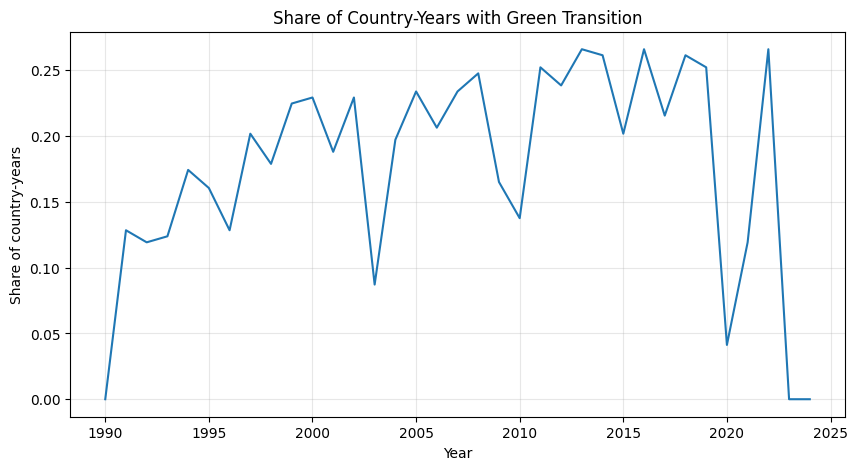

In [5]:

# Share of green-transition country-years over time
target_by_year = df.groupby("year")[TARGET].mean()

plt.figure(figsize=(10, 5))
target_by_year.plot()
plt.title(f"Share of Country-Years with {TARGET.replace('_', ' ').title()}")
plt.xlabel("Year")
plt.ylabel("Share of country-years")
plt.grid(True, alpha=0.3)
plt.show()


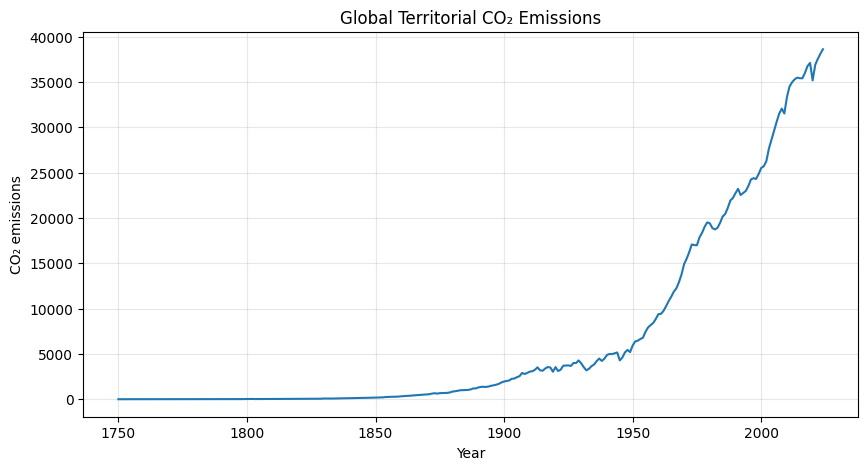

In [6]:

# Global CO2 trend from the dataset, using the World aggregate if available.
world = df_raw[df_raw["country"].eq("World")].copy()

if not world.empty:
    plt.figure(figsize=(10, 5))
    plt.plot(world["year"], world["co2"])
    plt.title("Global Territorial CO₂ Emissions")
    plt.xlabel("Year")
    plt.ylabel("CO₂ emissions")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("World aggregate not available in this file.")


## 6. Modelling Helper — Same Logic as the Speed-Dating Notebook

In [7]:

def standardize_features(model_data, features):
    """Standardize features so coefficients are comparable: one unit = one standard deviation."""
    model_data = model_data.copy()
    stats = {}

    for feature in features:
        mean = model_data[feature].mean()
        std = model_data[feature].std()
        stats[feature] = {"mean": mean, "std": std}

        if pd.notna(std) and std > 0:
            model_data[feature] = (model_data[feature] - mean) / std
        else:
            model_data[feature] = model_data[feature] - mean

    return model_data, stats


def run_logit_model(df, features, target=TARGET, title="", standardize=True, return_data=False):
    print(f"\n{'='*80}")
    print(f" {title}")
    print(f"{'='*80}")

    model_data = df[[target] + features].replace([np.inf, -np.inf], np.nan).dropna().copy()

    if model_data.empty:
        print("No complete cases available for these features.")
        return None

    if model_data[target].nunique() < 2:
        print("Target has only one class after dropping missing values.")
        return None

    if standardize:
        model_data, scaling_stats = standardize_features(model_data, features)
    else:
        scaling_stats = None

    X = sm.add_constant(model_data[features])
    y = model_data[target]

    try:
        model = sm.Logit(y, X).fit(disp=0, maxiter=200)
        print(model.summary())

        result_table = pd.DataFrame({
            "coef_log_odds": model.params,
            "odds_ratio": np.exp(model.params),
            "p_value": model.pvalues
        })

        print("\n--- Clean coefficient table ---")
        display(result_table)

        print("\n--- Plain-language interpretation ---")
        print(f"Observations used: {len(model_data):,}")
        print(f"Pseudo-R²: {model.prsquared:.4f}")

        for feature in features:
            coef = model.params[feature]
            pval = model.pvalues[feature]
            direction = "increases" if coef > 0 else "decreases"
            sig = "SIGNIFICANT" if pval < 0.05 else "NOT significant"
            print(
                f"[{feature}] {sig} (p={pval:.4f}). "
                f"A one-standard-deviation increase {direction} the log-odds of {target}=1 "
                f"(coef={coef:.4f}, odds ratio={np.exp(coef):.3f})."
            )

        if return_data:
            return model, model_data, scaling_stats

        return model

    except Exception as exc:
        print(f"Model error: {exc}")
        return None



# 7. Hypotheses

The hypotheses follow the same logic as the speed-dating notebook: each model tests a simple idea separately.

## H1 — Economic Development

**Question:** Are richer economies more likely to achieve a green-transition year?

\[
\log\left(\frac{P}{1-P}\right)=\beta_0+\beta_1 \log(GDPpc_{t-1})
\]


In [8]:
h1_features = ["log_gdp_per_capita_lag1"]
run_logit_model(df, h1_features, title="H1: Economic Development and Green Transition")


 H1: Economic Development and Green Transition
                           Logit Regression Results                           
Dep. Variable:       green_transition   No. Observations:                 5410
Model:                          Logit   Df Residuals:                     5408
Method:                           MLE   Df Model:                            1
Date:                Thu, 21 May 2026   Pseudo R-squ.:                 0.01290
Time:                        16:57:29   Log-Likelihood:                -3011.1
converged:                       True   LL-Null:                       -3050.4
Covariance Type:            nonrobust   LLR p-value:                 7.203e-19
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -1.1111      0.032    -34.842      0.000      -1.174      -1.049
log_gdp_per_capita_lag1     0.2830      0.03

,coef_log_odds,odds_ratio,p_value
const,-1.111077,0.329204,5.714219e-266
log_gdp_per_capita_lag1,0.283034,1.327150,2.142956e-18



--- Plain-language interpretation ---
Observations used: 5,410
Pseudo-R²: 0.0129
[log_gdp_per_capita_lag1] SIGNIFICANT (p=0.0000). A one-standard-deviation increase increases the log-odds of green_transition=1 (coef=0.2830, odds ratio=1.327).



## H2 — Energy Intensity

**Question:** Does the amount of energy needed per unit of GDP affect the probability of a green-transition year?

In the course logic, energy demand is strongly linked to capital stock, intensity of use, and efficiency. At the aggregate level, `energy_per_gdp` is a compact proxy for how energy-intensive production is.


In [9]:
h2_features = ["energy_per_gdp_lag1"]
run_logit_model(df, h2_features, title="H2: Energy Intensity")


 H2: Energy Intensity
                           Logit Regression Results                           
Dep. Variable:       green_transition   No. Observations:                 5359
Model:                          Logit   Df Residuals:                     5357
Method:                           MLE   Df Model:                            1
Date:                Thu, 21 May 2026   Pseudo R-squ.:                0.001374
Time:                        16:57:29   Log-Likelihood:                -3024.9
converged:                       True   LL-Null:                       -3029.1
Covariance Type:            nonrobust   LLR p-value:                  0.003907
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -1.0862      0.031    -34.502      0.000      -1.148      -1.024
energy_per_gdp_lag1     0.0861      0.029      2.932      0.003       0.029      

,coef_log_odds,odds_ratio,p_value
const,-1.086176,0.337505,7.401643e-261
energy_per_gdp_lag1,0.086056,1.089868,3.369464e-03



--- Plain-language interpretation ---
Observations used: 5,359
Pseudo-R²: 0.0014
[energy_per_gdp_lag1] SIGNIFICANT (p=0.0034). A one-standard-deviation increase increases the log-odds of green_transition=1 (coef=0.0861, odds ratio=1.090).



## H3 — Carbon Intensity of Energy

**Question:** Does a cleaner energy mix make green-transition years more likely?

`co2_per_unit_energy` is interpreted as the emissions intensity of the energy system.


In [10]:
h3_features = ["co2_per_unit_energy_lag1"]
run_logit_model(df, h3_features, title="H3: Carbon Intensity of Energy")


 H3: Carbon Intensity of Energy
                           Logit Regression Results                           
Dep. Variable:       green_transition   No. Observations:                 6830
Model:                          Logit   Df Residuals:                     6828
Method:                           MLE   Df Model:                            1
Date:                Thu, 21 May 2026   Pseudo R-squ.:               2.365e-05
Time:                        16:57:29   Log-Likelihood:                -3401.0
converged:                       True   LL-Null:                       -3401.0
Covariance Type:            nonrobust   LLR p-value:                    0.6883
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -1.3974      0.030    -46.039      0.000      -1.457      -1.338
co2_per_unit_energy_lag1     0.0115      0.028      0.41

,coef_log_odds,odds_ratio,p_value
const,-1.397351,0.247251,0.000000
co2_per_unit_energy_lag1,0.011462,1.011528,0.680585



--- Plain-language interpretation ---
Observations used: 6,830
Pseudo-R²: 0.0000
[co2_per_unit_energy_lag1] NOT significant (p=0.6806). A one-standard-deviation increase increases the log-odds of green_transition=1 (coef=0.0115, odds ratio=1.012).



## H4 — Coal Dependence

**Question:** Does a higher coal share in CO₂ emissions make transition harder?

Coal dependence is proxied as:

\[
CoalShareCO2 = \frac{CoalCO2}{TotalCO2}
\]


In [11]:
h4_features = ["coal_share_co2_lag1"]
run_logit_model(df, h4_features, title="H4: Coal Dependence")


 H4: Coal Dependence
                           Logit Regression Results                           
Dep. Variable:       green_transition   No. Observations:                 4615
Model:                          Logit   Df Residuals:                     4613
Method:                           MLE   Df Model:                            1
Date:                Thu, 21 May 2026   Pseudo R-squ.:                0.004269
Time:                        16:57:29   Log-Likelihood:                -2513.2
converged:                       True   LL-Null:                       -2523.9
Covariance Type:            nonrobust   LLR p-value:                 3.444e-06
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -1.1789      0.035    -33.843      0.000      -1.247      -1.111
coal_share_co2_lag1     0.1568      0.033      4.691      0.000       0.091       

,coef_log_odds,odds_ratio,p_value
const,-1.178891,0.307620,4.646465e-251
coal_share_co2_lag1,0.156793,1.169753,2.722967e-06



--- Plain-language interpretation ---
Observations used: 4,615
Pseudo-R²: 0.0043
[coal_share_co2_lag1] SIGNIFICANT (p=0.0000). A one-standard-deviation increase increases the log-odds of green_transition=1 (coef=0.1568, odds ratio=1.170).



## H5 — Oil and Gas Dependence

**Question:** Do oil and gas emission shares have different associations with green-transition outcomes?


In [12]:
h5_features = ["oil_share_co2_lag1", "gas_share_co2_lag1"]
run_logit_model(df, h5_features, title="H5: Oil and Gas Dependence")


 H5: Oil and Gas Dependence
                           Logit Regression Results                           
Dep. Variable:       green_transition   No. Observations:                 4129
Model:                          Logit   Df Residuals:                     4126
Method:                           MLE   Df Model:                            2
Date:                Thu, 21 May 2026   Pseudo R-squ.:                0.008581
Time:                        16:57:29   Log-Likelihood:                -2286.3
converged:                       True   LL-Null:                       -2306.1
Covariance Type:            nonrobust   LLR p-value:                 2.548e-09
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -1.1299      0.037    -30.949      0.000      -1.201      -1.058
oil_share_co2_lag1    -0.2655      0.042     -6.285      0.000      -0.348    

,coef_log_odds,odds_ratio,p_value
const,-1.129855,0.323080,2.641081e-210
oil_share_co2_lag1,-0.265524,0.766804,3.272124e-10
gas_share_co2_lag1,-0.126891,0.880830,2.116113e-03



--- Plain-language interpretation ---
Observations used: 4,129
Pseudo-R²: 0.0086
[oil_share_co2_lag1] SIGNIFICANT (p=0.0000). A one-standard-deviation increase decreases the log-odds of green_transition=1 (coef=-0.2655, odds ratio=0.767).
[gas_share_co2_lag1] SIGNIFICANT (p=0.0021). A one-standard-deviation increase decreases the log-odds of green_transition=1 (coef=-0.1269, odds ratio=0.881).



## H6 — Population Scale

**Question:** Are larger countries structurally more or less likely to achieve a green-transition year?

This is not a moral claim. It tests whether scale makes emissions reduction easier or harder in the observed data.


In [13]:
h6_features = ["log_population_lag1"]
run_logit_model(df, h6_features, title="H6: Population Scale")


 H6: Population Scale
                           Logit Regression Results                           
Dep. Variable:       green_transition   No. Observations:                 7344
Model:                          Logit   Df Residuals:                     7342
Method:                           MLE   Df Model:                            1
Date:                Thu, 21 May 2026   Pseudo R-squ.:                 0.03942
Time:                        16:57:29   Log-Likelihood:                -3380.3
converged:                       True   LL-Null:                       -3519.0
Covariance Type:            nonrobust   LLR p-value:                 2.713e-62
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -1.5744      0.033    -48.223      0.000      -1.638      -1.510
log_population_lag1     0.5602      0.036     15.493      0.000       0.489      

,coef_log_odds,odds_ratio,p_value
const,-1.574362,0.207140,0.000000e+00
log_population_lag1,0.560151,1.750937,3.858021e-54



--- Plain-language interpretation ---
Observations used: 7,344
Pseudo-R²: 0.0394
[log_population_lag1] SIGNIFICANT (p=0.0000). A one-standard-deviation increase increases the log-odds of green_transition=1 (coef=0.5602, odds ratio=1.751).



## H7 — Global Emitter Size

**Question:** Are countries with a larger share of global CO₂ emissions more or less likely to achieve a green-transition year?


In [14]:
h7_features = ["share_global_co2_lag1"]
run_logit_model(df, h7_features, title="H7: Global Emitter Size")


 H7: Global Emitter Size
                           Logit Regression Results                           
Dep. Variable:       green_transition   No. Observations:                 7293
Model:                          Logit   Df Residuals:                     7291
Method:                           MLE   Df Model:                            1
Date:                Thu, 21 May 2026   Pseudo R-squ.:               0.0002424
Time:                        16:57:29   Log-Likelihood:                -3507.7
converged:                       True   LL-Null:                       -3508.5
Covariance Type:            nonrobust   LLR p-value:                    0.1922
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -1.4735      0.030    -48.994      0.000      -1.532      -1.415
share_global_co2_lag1     0.0366      0.027      1.345      0.179      -

,coef_log_odds,odds_ratio,p_value
const,-1.473467,0.229130,0.000000
share_global_co2_lag1,0.036591,1.037268,0.178627



--- Plain-language interpretation ---
Observations used: 7,293
Pseudo-R²: 0.0002
[share_global_co2_lag1] NOT significant (p=0.1786). A one-standard-deviation increase increases the log-odds of green_transition=1 (coef=0.0366, odds ratio=1.037).



## H8 — Trade-Adjusted CO₂ Position

**Question:** Does the consumption-production emissions gap matter?

`trade_co2_share` helps show whether emissions are being imported/exported through trade rather than only produced domestically.


In [15]:
h8_features = ["trade_co2_share_lag1"]
run_logit_model(df, h8_features, title="H8: Trade-Adjusted CO2 Position")


 H8: Trade-Adjusted CO2 Position
                           Logit Regression Results                           
Dep. Variable:       green_transition   No. Observations:                 4063
Model:                          Logit   Df Residuals:                     4061
Method:                           MLE   Df Model:                            1
Date:                Thu, 21 May 2026   Pseudo R-squ.:               2.594e-05
Time:                        16:57:29   Log-Likelihood:                -2309.9
converged:                       True   LL-Null:                       -2310.0
Covariance Type:            nonrobust   LLR p-value:                    0.7292
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -1.0684      0.036    -29.708      0.000      -1.139      -0.998
trade_co2_share_lag1    -0.0126      0.037     -0.344      0.731   

,coef_log_odds,odds_ratio,p_value
const,-1.068361,0.343571,5.994574e-194
trade_co2_share_lag1,-0.012599,0.987480,7.308066e-01



--- Plain-language interpretation ---
Observations used: 4,063
Pseudo-R²: 0.0000
[trade_co2_share_lag1] NOT significant (p=0.7308). A one-standard-deviation increase decreases the log-odds of green_transition=1 (coef=-0.0126, odds ratio=0.987).



## H9 — Time Trend

**Question:** Are green-transition years becoming more common over time?

This simple model captures broad technology, policy, and structural change over time.


In [16]:
h9_features = ["year_centered"]
run_logit_model(df, h9_features, title="H9: Time Trend")


 H9: Time Trend


                           Logit Regression Results                           
Dep. Variable:       green_transition   No. Observations:                 7630
Model:                          Logit   Df Residuals:                     7628
Method:                           MLE   Df Model:                            1
Date:                Thu, 21 May 2026   Pseudo R-squ.:               0.0004505
Time:                        16:57:29   Log-Likelihood:                -3574.7
converged:                       True   LL-Null:                       -3576.3
Covariance Type:            nonrobust   LLR p-value:                   0.07264
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.5292      0.030    -51.081      0.000      -1.588      -1.471
year_centered     0.0537      0.030      1.794      0.073      -0.005       0.112

--- Clean coefficient table ---


,coef_log_odds,odds_ratio,p_value
const,-1.52922,0.216705,0.000000
year_centered,0.05372,1.055189,0.072746



--- Plain-language interpretation ---
Observations used: 7,630
Pseudo-R²: 0.0005
[year_centered] NOT significant (p=0.0727). A one-standard-deviation increase increases the log-odds of green_transition=1 (coef=0.0537, odds ratio=1.055).



## H10 — Interaction: Income × Energy Intensity

**Question:** Does energy intensity change the role of income?

This interaction is useful for the video because it shows why structural estimation is not only about isolated correlations. The same income level may imply different transition probabilities depending on how energy-intensive the economy is.


In [17]:
h10_features = ["log_gdp_per_capita_lag1", "energy_per_gdp_lag1", "income_x_energy_intensity"]
run_logit_model(df, h10_features, title="H10: Income × Energy Intensity Interaction")


 H10: Income × Energy Intensity Interaction


                           Logit Regression Results                           
Dep. Variable:       green_transition   No. Observations:                 5359
Model:                          Logit   Df Residuals:                     5355
Method:                           MLE   Df Model:                            3
Date:                Thu, 21 May 2026   Pseudo R-squ.:                 0.01363
Time:                        16:57:29   Log-Likelihood:                -2987.8
converged:                       True   LL-Null:                       -3029.1
Covariance Type:            nonrobust   LLR p-value:                 8.517e-18
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -1.1060      0.032    -34.517      0.000      -1.169      -1.043
log_gdp_per_capita_lag1       0.3452      0.050      6.881      0.000       0.247     

,coef_log_odds,odds_ratio,p_value
const,-1.106041,0.330866,4.428462e-261
log_gdp_per_capita_lag1,0.345199,1.412270,5.936425e-12
energy_per_gdp_lag1,0.575312,1.777685,4.800034e-02
income_x_energy_intensity,-0.561113,0.570574,6.172552e-02



--- Plain-language interpretation ---
Observations used: 5,359
Pseudo-R²: 0.0136
[log_gdp_per_capita_lag1] SIGNIFICANT (p=0.0000). A one-standard-deviation increase increases the log-odds of green_transition=1 (coef=0.3452, odds ratio=1.412).
[energy_per_gdp_lag1] SIGNIFICANT (p=0.0480). A one-standard-deviation increase increases the log-odds of green_transition=1 (coef=0.5753, odds ratio=1.778).
[income_x_energy_intensity] NOT significant (p=0.0617). A one-standard-deviation increase decreases the log-odds of green_transition=1 (coef=-0.5611, odds ratio=0.571).



# 8. Combined Structural-Style Model

After testing the hypotheses separately, we combine several structural conditions into one model.

This is closer to the explanation needed for the video:

> A country-year does not transition because of one variable only. It is the result of income, energy intensity, carbon intensity, fuel mix, scale, trade position, and time.


In [18]:

combined_features = [
    "log_gdp_per_capita_lag1",
    "energy_per_gdp_lag1",
    "co2_per_unit_energy_lag1",
    "coal_share_co2_lag1",
    "oil_share_co2_lag1",
    "gas_share_co2_lag1",
    "log_population_lag1",
    "share_global_co2_lag1",
    "trade_co2_share_lag1",
    "year_centered",
    "income_x_energy_intensity"
]

combined_model, combined_data, scaling_stats = run_logit_model(
    df,
    combined_features,
    title="Combined Model: Structural Conditions of Green Transition",
    return_data=True
)



 Combined Model: Structural Conditions of Green Transition


                           Logit Regression Results                           
Dep. Variable:       green_transition   No. Observations:                 2718
Model:                          Logit   Df Residuals:                     2706
Method:                           MLE   Df Model:                           11
Date:                Thu, 21 May 2026   Pseudo R-squ.:                 0.02441
Time:                        16:57:29   Log-Likelihood:                -1579.6
converged:                       True   LL-Null:                       -1619.1
Covariance Type:            nonrobust   LLR p-value:                 2.263e-12
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -0.9667      0.044    -21.949      0.000      -1.053      -0.880
log_gdp_per_capita_lag1       0.5488      0.102      5.406      0.000       0.350     

,coef_log_odds,odds_ratio,p_value
const,-0.966696,0.380337,8.812784e-107
log_gdp_per_capita_lag1,0.548810,1.731192,6.444252e-08
energy_per_gdp_lag1,2.032013,7.629427,6.848247e-04
co2_per_unit_energy_lag1,0.036925,1.037616,5.318028e-01
coal_share_co2_lag1,0.147524,1.158961,5.211183e-01
oil_share_co2_lag1,0.060660,1.062538,7.870153e-01
gas_share_co2_lag1,-0.012093,0.987980,9.531701e-01
log_population_lag1,-0.099280,0.905489,9.984109e-02
share_global_co2_lag1,-0.124552,0.882893,5.410885e-02
trade_co2_share_lag1,0.004412,1.004422,9.309610e-01



--- Plain-language interpretation ---
Observations used: 2,718
Pseudo-R²: 0.0244
[log_gdp_per_capita_lag1] SIGNIFICANT (p=0.0000). A one-standard-deviation increase increases the log-odds of green_transition=1 (coef=0.5488, odds ratio=1.731).
[energy_per_gdp_lag1] SIGNIFICANT (p=0.0007). A one-standard-deviation increase increases the log-odds of green_transition=1 (coef=2.0320, odds ratio=7.629).
[co2_per_unit_energy_lag1] NOT significant (p=0.5318). A one-standard-deviation increase increases the log-odds of green_transition=1 (coef=0.0369, odds ratio=1.038).
[coal_share_co2_lag1] NOT significant (p=0.5211). A one-standard-deviation increase increases the log-odds of green_transition=1 (coef=0.1475, odds ratio=1.159).
[oil_share_co2_lag1] NOT significant (p=0.7870). A one-standard-deviation increase increases the log-odds of green_transition=1 (coef=0.0607, odds ratio=1.063).
[gas_share_co2_lag1] NOT significant (p=0.9532). A one-standard-deviation increase decreases the log-odds of


## 9. Counterfactual Simulation

This is the most important part for linking to **structural estimation**.

Reduced-form / ML question:

> Can we predict which country-years transition?

Structural-style question:

> If the structural conditions changed, how would the predicted probability change?

The following simulation changes selected standardized variables and compares average predicted probabilities. This should be presented carefully as a **model-based counterfactual**, not as causal proof.


,scenario,average_predicted_probability,change_vs_baseline_pp
0,Baseline,0.282929,0.000000
1,Lower energy intensity (-0.5 SD),0.127326,-15.560312
2,Lower carbon intensity (-0.5 SD),0.279301,-0.362808
3,Lower coal share (-0.5 SD),0.268601,-1.432809


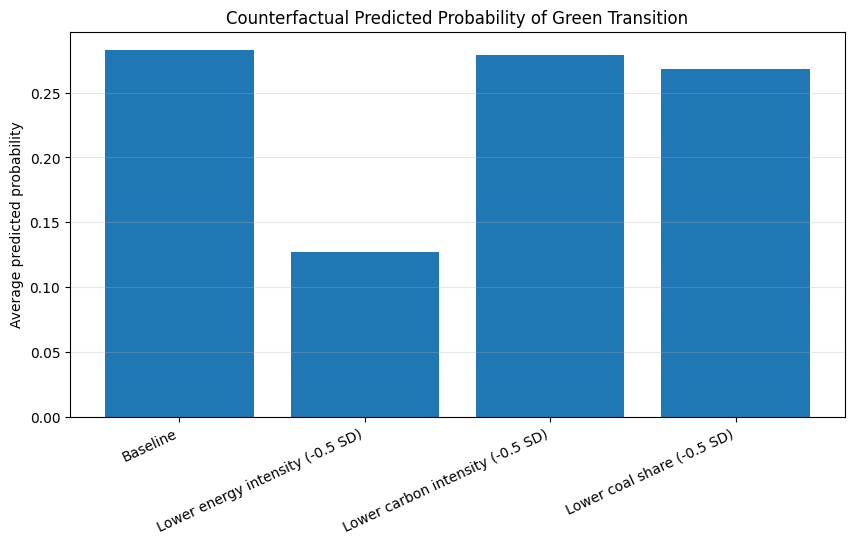

In [19]:

def average_predicted_probability(model, standardized_data, features):
    X = sm.add_constant(standardized_data[features], has_constant="add")
    return model.predict(X).mean()


if combined_model is not None:
    baseline_prob = average_predicted_probability(combined_model, combined_data, combined_features)

    scenarios = {}

    # Since variables are standardized, subtracting 0.5 means a half-standard-deviation reduction.
    scenario_a = combined_data.copy()
    scenario_a["energy_per_gdp_lag1"] = scenario_a["energy_per_gdp_lag1"] - 0.5
    scenarios["Lower energy intensity (-0.5 SD)"] = average_predicted_probability(combined_model, scenario_a, combined_features)

    scenario_b = combined_data.copy()
    scenario_b["co2_per_unit_energy_lag1"] = scenario_b["co2_per_unit_energy_lag1"] - 0.5
    scenarios["Lower carbon intensity (-0.5 SD)"] = average_predicted_probability(combined_model, scenario_b, combined_features)

    scenario_c = combined_data.copy()
    scenario_c["coal_share_co2_lag1"] = scenario_c["coal_share_co2_lag1"] - 0.5
    scenarios["Lower coal share (-0.5 SD)"] = average_predicted_probability(combined_model, scenario_c, combined_features)

    cf_table = pd.DataFrame({
        "scenario": ["Baseline"] + list(scenarios.keys()),
        "average_predicted_probability": [baseline_prob] + list(scenarios.values())
    })

    cf_table["change_vs_baseline_pp"] = (
        cf_table["average_predicted_probability"] - baseline_prob
    ) * 100

    display(cf_table)

    plt.figure(figsize=(10, 5))
    plt.bar(cf_table["scenario"], cf_table["average_predicted_probability"])
    plt.title("Counterfactual Predicted Probability of Green Transition")
    plt.ylabel("Average predicted probability")
    plt.xticks(rotation=25, ha="right")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()
else:
    print("Combined model was not estimated successfully.")



# 10. Suggested Video Narrative

Use this structure:

1. **Hook**  
   “In speed dating, we asked: what makes someone say yes? In climate policy, we ask: what makes a country-year say yes to growth with lower emissions?”

2. **Structural estimation intuition**  
   “We do not only predict outcomes. We estimate the hidden index behind the observed binary outcome.”

3. **Binary decision**  
   “Yes = green-transition year. No = not a green-transition year.”

4. **Latent utility**  
   “The country-year crosses the threshold when structural conditions are favorable enough: income, energy intensity, fuel mix, carbon intensity, and scale.”

5. **Hypotheses**  
   “Just like attractiveness, age difference, and interests in dating, we now test energy intensity, fossil dependence, and development level.”

6. **Counterfactual**  
   “The value of structural estimation is that we can ask: what if energy intensity were lower? What if carbon intensity were lower? What if coal dependence were lower?”

7. **Bridge to dynamic structural estimation**  
   “This is still a static model. The next step would be dynamic: countries choose investments and policies today while considering future climate damages, energy costs, and technology change. That is where models like DICE become relevant.”



# 11. Final Caveat

This notebook is designed for learning and explanation.

It should be described as:

> “a simplified static structural-style binary logit model using aggregate country-year data.”

Do not present it as a full causal structural estimation or a full dynamic climate-economy model. For the project, it works as the bridge between:

- the speed-dating intuition,
- static binary logit,
- energy/climate analytics,
- and the later dynamic DICE-style extension.
